In [1]:
import sys
sys.path.append("../")

from config import *
from figs_config import *

Loaded aesthetics module


# Empirical surface maps

Here we explore surface-based data from the datasets available through `neuromaps`

* aesthetics

In [2]:
corder = ['gene expression', 'MEG', 'structural', 'functional', 'metabolism', 'expansion']
ccolours = [
    to_hex(plt.cm.terrain(0.2)),  # gene: light turquoise
    to_hex(plt.cm.spring(0.65)),  # MEG: orange
    to_hex(plt.cm.cubehelix(0.7)),  # structural: violet
    to_hex(plt.cm.terrain(0.3)),  # functional: green
    to_hex(plt.cm.nipy_spectral(0.3)), # metabolism: blue
    to_hex(plt.cm.spring(0.37)) # expansion: pink
]

cpal = dict(zip(corder, ccolours))
sns.color_palette(ccolours)

[(0.0, 0.6980392156862745, 0.6980392156862745),
 (1.0, 0.6509803921568628, 0.34901960784313724),
 (0.8117647058823529, 0.615686274509804, 0.8588235294117647),
 (0.19215686274509805, 0.8392156862745098, 0.4392156862745098),
 (0.0, 0.596078431372549, 0.8666666666666667),
 (1.0, 0.3686274509803922, 0.6313725490196078)]

In [3]:
import pandas as pd
maptags = pd.read_table(projdir + '/data/surf_map_names', delimiter = " ", dtype = str)
maptags = list(maptags.columns)

In [4]:
space = 'fsLR-4k'
#maptag = 'abagen_genepc1'
geometry = 'reduced-midthickness'
datasource = 'neuromaps'
strategy = 'dsk33'
#percentage = 5
niters = 100

In [5]:
import joblib
src_pvdata = joblib.load( projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

# Data

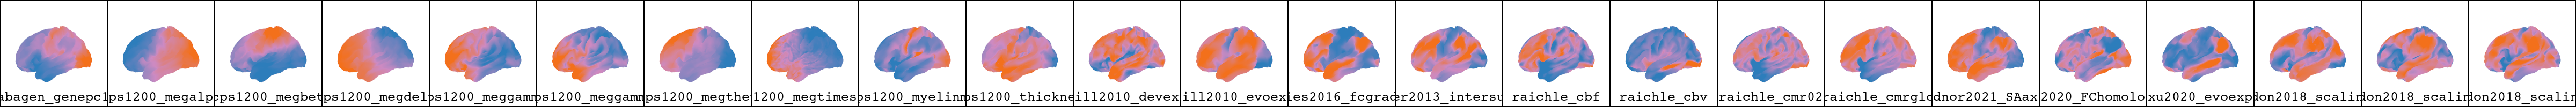

In [6]:
import pyvista as pv

pl = pv.Plotter(shape = (1, len(maptags)), window_size = (4800, 200))

for mi, maptag in enumerate(maptags):
    pl.subplot(0,mi)
    pl.add_mesh(src_pvdata.rotate_z(180), scalars=maptag, cmap = bpr, \
                clim = (np.percentile(src_pvdata[maptag], 5), np.percentile(src_pvdata[maptag], 95)), \
                **mesh_aes)
    pl.add_text(maptag, font_size = 10, font='courier', position = 'lower_edge')
    pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

# Moran scatterplots of the original maps

In [7]:
from interpmodules import helpers

global_i_s = pd.DataFrame(index = maptags, columns = ['i'])

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for maptag in maptags:
    global_i = helpers.morans_i(Dist, src_pvdata[maptag], normalize=True)
    global_i_s.loc[maptag] = global_i

In [8]:
from scipy.sparse import coo_matrix

dist = 1 / Dist
np.fill_diagonal(dist, 0)
dist /= dist.sum(axis=-1, keepdims=True)
spdist = coo_matrix(dist)

/tmp/ipykernel_44704/313955750.py:3: RuntimeWarning: divide by zero encountered in divide
  dist = 1 / Dist


In [9]:
def moran_permutation_test(x, W, n_perm, seed=0):
    rng = np.random.default_rng(seed)

    I_obs = helpers.morans_i(W, x, normalize=True, local=False, invert_dist=True)
    z = x - np.mean(x)

    # precompute denom for speed; permuting z doesn't change denom
    denom = np.dot(z, z)
    if denom == 0:
        return I_obs, np.nan, None

    Iz = np.empty(n_perm, dtype=float)
    for b in range(n_perm):
        zp = rng.permutation(z)
        Iz[b] = np.dot(zp, W @ zp) / denom

    # two sided
    p = (np.sum(np.abs(Iz) >= abs(I_obs)) + 1) / (n_perm + 1)

    return I_obs, p, Iz

In [10]:
pperm = np.zeros(len(maptags))
for mi, maptag in enumerate(maptags):
    pperm[mi] = moran_permutation_test(src_pvdata[maptag], dist, n_perm=1000)[1]

In [11]:
pperm

array([0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999,
       0.000999, 0.000999, 0.000999, 0.000999, 0.000999, 0.000999])

In [41]:
maptocat = {'gene expression': ['abagen_genepc1'], \
            'MEG': ['hcps1200_meg' + fband for fband in fbands ] + ['hcps1200_megtimescale'], \
            'structural': ['hcps1200_thickness', 'hcps1200_myelinmap'], \
            'functional': ['margulies2016_fcgradient01', 'mueller2013_intersubjvar', 'xu2020_FChomology', 'sydnor2021_SAaxis'], \
            'metabolism': ['raichle_cbf', 'raichle_cbv', 'raichle_cmr02', 'raichle_cmrglc'], \
            'expansion': ['hill2010_devexp', 'hill2010_evoexp', 'xu2020_evoexp', 'reardon2018_scalinghcp', 'reardon2018_scalingnih', 'reardon2018_scalingpnc']}

In [44]:
cat = []
for row in range(len(global_i_s)):
    for category in maptocat:
        if global_i_s.index[row] in maptocat[category]:
            cat.append( category )
        else: continue

global_i_s['category'] = cat

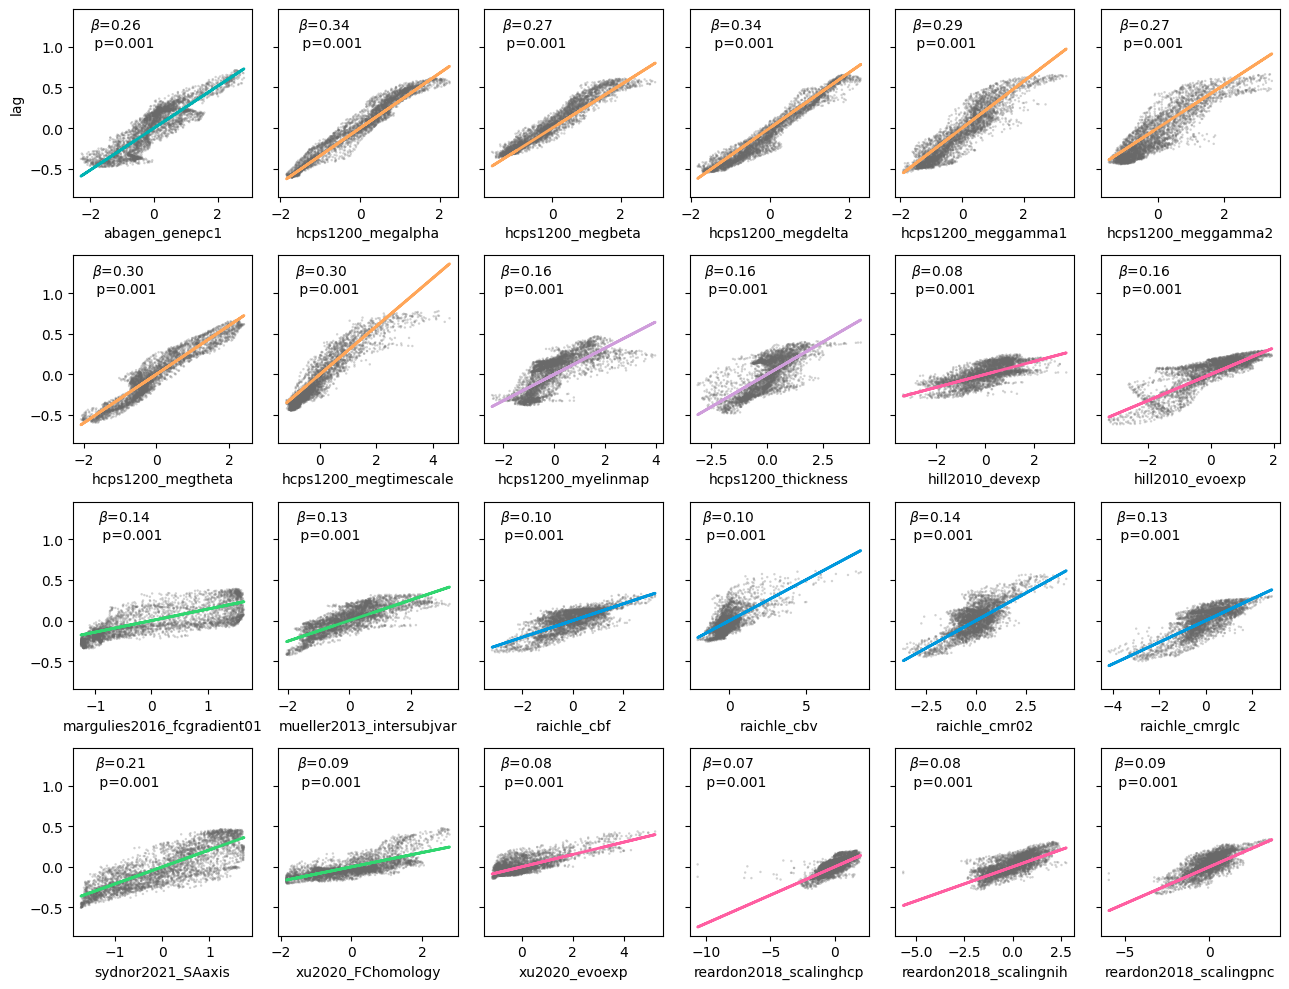

In [45]:
from scipy.stats import zscore

fig, axs = plt.subplots(4, 6, figsize = (13, 10), sharey=True)

moran_scatter = pd.DataFrame()

for mi, maptag in enumerate(global_i_s.index):


    row, col = mi // 6, mi % 6
    
    zX = zscore(src_pvdata[maptag])
    #splag = np.average(np.repeat(zX[np.newaxis], src_pvdata.n_points, axis=0), weights=spdist, axis=1)
    splag = spdist @ zX
    normalized_og = zscore(src_pvdata[maptag])
    axs[row, col].scatter(x = zX, y =splag, s=3, c='dimgray', edgecolor = 'none', alpha = .3, rasterized = True)
    axs[row, col].set_xlabel(maptag)
    axs[0,0].set_ylabel("lag")

    #axs[mi].axhline(0, color="k", lw=1)
    #axs[mi].axvline(0, color="k", lw=1)
    
    # regression line
    m = (zX @ splag) / (zX @ zX)   # Moran's I
    moran_scatter.at[maptag,0] = m
    axs[row,col].plot(zX, m * zX, linewidth = 2, color=cpal[global_i_s.at[maptag, 'category']])
    axs[row,col].text(x=zX.min() + 0.3, y=1, s=r"$\beta$=" + "%.2f" % m + "\n p=0.001")
plt.tight_layout()
plt.show()

In [99]:
global_i_s

,i,category
abagen_genepc1,0.258006,gene expression
hcps1200_megalpha,0.33919,MEG
hcps1200_megbeta,0.265799,MEG
hcps1200_megdelta,0.339774,MEG
hcps1200_meggamma1,0.288112,MEG
hcps1200_meggamma2,0.267007,MEG
hcps1200_megtheta,0.299977,MEG
hcps1200_megtimescale,0.296607,MEG
hcps1200_myelinmap,0.161553,structural
hcps1200_thickness,0.159796,structural


In [ ]:
# Compute global Moran's I for the samples

sample_global_i_s = np.zeros((len(test_percentages), len(maptags), niters))

for pi, percentage in enumerate(test_percentages):

    sampling = joblib.load( projdir + f'/data/sampling/{space}_{geometry}_samp-{strategy}_pct-{str(percentage)}_iters-100.pkl')
    known_coords, known_verts, unknown_coords, unknown_verts = sampling[1]

    for mi, maptag in enumerate(maptags):
        for j in range(niters):
            dj = helpers.internal_distance_matrix(known_coords[:,:,j])
            xj = src_pvdata[maptag][known_verts[:,j].flatten().astype(int)]
    
            sample_global_i_s[pi, mi, j] = helpers.morans_i(dj, xj)
# it took a while so i'm saving it
#np.save(projdir + '/results/neuromaps_samples_global_i_s.npy', sample_global_i_s)

In [100]:
sample_global_i_s = np.load(projdir + '/results/stats/neuromaps_samples_global_i_s.npy')

In [101]:
sample_global_i_s.shape

(4, 24, 100)

In [102]:
samples_i_s = pd.DataFrame(sample_global_i_s.mean(axis=0).T, columns=[maptags], index=np.arange(100))

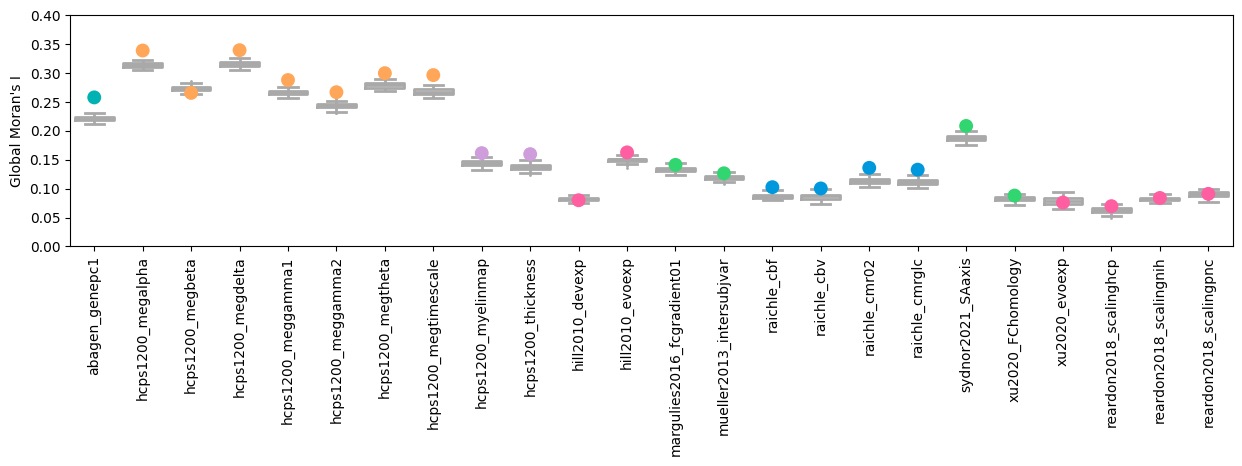

In [104]:
import seaborn as sns

plt.figure(figsize = (15,3))

sns.scatterplot(global_i_s, x=global_i_s.index, y='i', \
                hue = 'category', hue_order = corder, \
                palette = cpal, edgecolor = 'none',  s = 100, legend = False, zorder = 10
)

sns.boxplot( samples_i_s, color='darkgray', fliersize=1, linewidth = 2, fill=False)


plt.ylim([0,.4])
plt.xticks(rotation=90)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("Global Moran's I")
plt.show()

# Variography

## distance binning

In [46]:
import matplotlib.pyplot as plt
nh = 25
X = src_pvdata.points

In [49]:
EDist = helpers.internal_distance_matrix(src_pvdata.points, "euclidean")


In [47]:
import neuromaps.datasets
import nibabel as nb

fs4k = neuromaps.datasets.fetch_atlas(atlas='fsLR', density='4k')

gimg = nb.load(fs4k['midthickness'].L)
v,f = gimg.darrays[0].data, gimg.darrays[1].data
GDist = helpers.internal_distance_matrix(v,f, "geodesic")

In [50]:
medialwall = joblib.load(projdir + '/data/fsLR-4k_midthickness_neuromaps_medial_wall_mask.pkl')

In [51]:
tmp = np.delete(GDist, medialwall, axis=0)
tmp1 = np.delete(tmp, medialwall, axis=1)

In [52]:
GDist = tmp1

In [53]:
import pandas as pd

N = dict.fromkeys(['euclidean', 'geodesic'])

In [55]:
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree

for method in ['euclidean', 'geodesic']:
    
    if method == 'euclidean':
        max_lag = np.nanmax(EDist)
        tree = KDTree(src_pvdata.points)
        spdist = tree.sparse_distance_matrix(tree, max_distance=max_lag, output_type='coo_matrix')
    
    elif method == 'geodesic':
        max_lag = np.nanmax(GDist)
        spdist = coo_matrix(GDist)

    i_idx = spdist.row
    j_idx = spdist.col
    dist_ij = spdist.data
    
    df = pd.DataFrame({
        'h': dist_ij,
    })
    
    bin_edges = np.linspace(0.000001, max_lag, nh + 1)
    df['bins'] = pd.cut(df['h'], bin_edges)

    N[method] = df.groupby('bins')['h'].count().values

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,nh))
cmap_discrete = ListedColormap(colors)

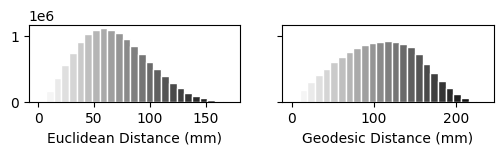

In [57]:
figs, axs = plt.subplots(1,2, figsize = (6,1), sharey=True)

bin_edges = np.linspace(0.000001, np.nanmax(EDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

axs[0].bar(x=bincenters, height=N["euclidean"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
axs[0].set_xlabel("Euclidean Distance (mm)")

bin_edges = np.linspace(0.000001, np.nanmax(GDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

axs[1].bar(x=bincenters, height=N["geodesic"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
axs[1].set_xlabel("Geodesic Distance (mm)")

plt.show()

In [58]:
np.where(N['euclidean'] == N['euclidean'].max())

(array([8]),)

In [59]:
print(bin_edges[7], bin_edges[8])

65.63982 75.01694


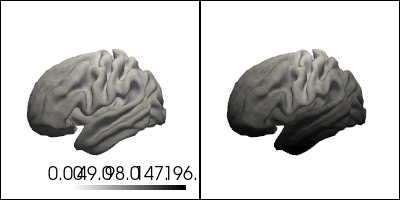

In [60]:
import copy
import pyvista as pv
from matplotlib.colors import ListedColormap
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(shape = (1,2), window_size = (400,200))

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_mesh(copy.deepcopy(src_pvdata).rotate_z(200), scalars=EDist[500], smooth_shading=True, opacity=1, cmap = cmap_discrete)
pl.camera_position = 'yz'

pl.subplot(0,1)
pl.add_mesh(copy.deepcopy(src_pvdata).rotate_z(200), scalars=GDist[500], smooth_shading=True, opacity =1, cmap = cmap_discrete)

pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

## functional PCA

In [61]:
import joblib

# h should be the same
nh = 25
all_ev = np.zeros((nh, len(maptags)))

for mi, maptag in enumerate(maptags):

    h, ev, _ = helpers.get_empirical_variogram_fast(x=src_pvdata[maptag], X=src_pvdata.points, D=Dist,nh=nh)
    all_ev[:,mi] = ev

In [62]:
from skfda.representation.grid import FDataGrid

all_ev_z = zscore(all_ev, axis = 0)
datag = FDataGrid(all_ev_z)

In [63]:
import skfda

fpca = skfda.preprocessing.dim_reduction.FPCA(n_components=3, )

In [64]:
fpca.fit(datag)

FPCA(_weights=array([0.01449275, 0.05797101, 0.02898551, 0.05797101, 0.02898551,
       0.05797101, 0.02898551, 0.05797101, 0.02898551, 0.05797101,
       0.02898551, 0.05797101, 0.02898551, 0.05797101, 0.02898551,
       0.05797101, 0.02898551, 0.05797101, 0.02898551, 0.05797101,
       0.02898551, 0.05434783, 0.04347826, 0.01811594]),
     n_components=3)

In [65]:
maptags

['abagen_genepc1',
 'hcps1200_megalpha',
 'hcps1200_megbeta',
 'hcps1200_megdelta',
 'hcps1200_meggamma1',
 'hcps1200_meggamma2',
 'hcps1200_megtheta',
 'hcps1200_megtimescale',
 'hcps1200_myelinmap',
 'hcps1200_thickness',
 'hill2010_devexp',
 'hill2010_evoexp',
 'margulies2016_fcgradient01',
 'mueller2013_intersubjvar',
 'raichle_cbf',
 'raichle_cbv',
 'raichle_cmr02',
 'raichle_cmrglc',
 'sydnor2021_SAaxis',
 'xu2020_FChomology',
 'xu2020_evoexp',
 'reardon2018_scalinghcp',
 'reardon2018_scalingnih',
 'reardon2018_scalingpnc']

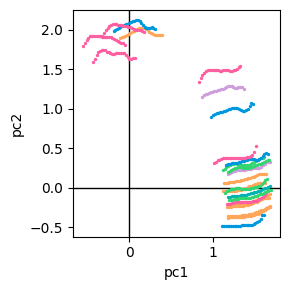

In [68]:
import matplotlib.pyplot as plt


plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

for x, y, mi in zip(xs, ys, np.arange(len(maptags))):
    plt.scatter(
        x + h*0.003,
        y + all_ev_z[:,mi]*0.04,
        color=cpal[global_i_s.at[maptags[mi], 'category']],
        alpha=1, s = 2, zorder = 10
    )

plt.scatter(xs, ys, s=0, zorder=10)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()
#plt.show()

In [69]:
fpca.explained_variance_

array([0.74224887, 0.2084329 , 0.0535849 ])

In [70]:
fpca.singular_values_

array([4.22066025, 2.23660227, 1.13403603])

In [71]:
pcs = fpca.fit_transform(datag)

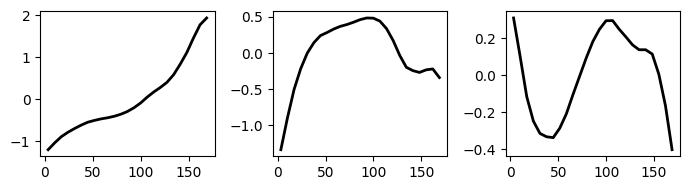

In [72]:
fig, axs = plt.subplots(1,3, figsize = (7, 2))

for c in range(fpca.n_components):
    axs[c].plot(h, pcs[:,c], color = 'k', linewidth=2)

plt.tight_layout()

## Exprimental variograms as little squares

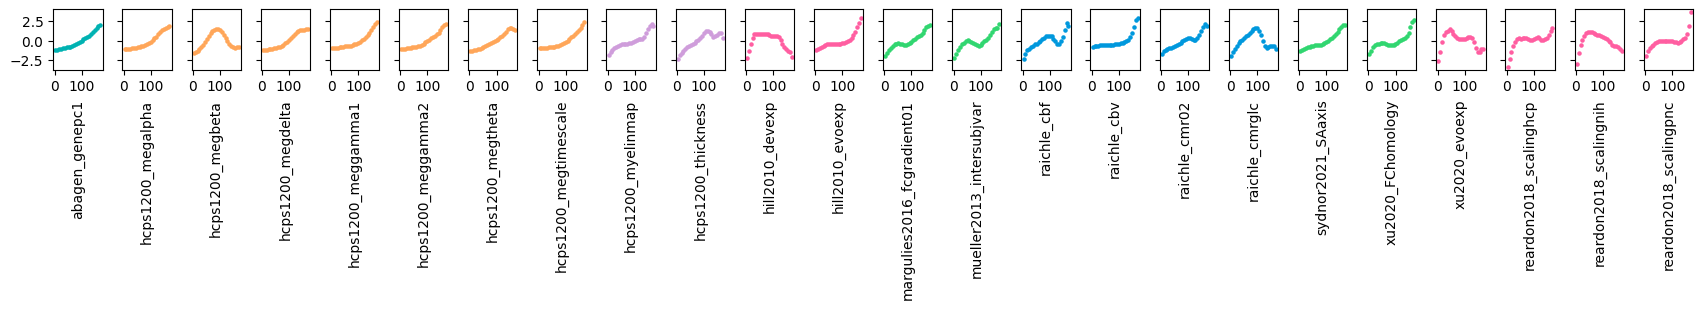

In [73]:
fig, axs = plt.subplots(1, len(maptags), figsize = (17,3.25), sharex=True, sharey=True)

for mi, maptag in enumerate(maptags):
    axs[mi].scatter( x=h, y=zscore(all_ev[:,mi]), color=cpal[global_i_s.at[maptag, 'category']], s=5 )
    axs[mi].set_xlabel(maptag, rotation = 90)
plt.tight_layout()
#plt.show()

In [108]:
global_i_s['pc1'] = np.array(fpca.components_[0].data_matrix).flatten()
global_i_s['pc2'] = np.array(fpca.components_[1].data_matrix).flatten()

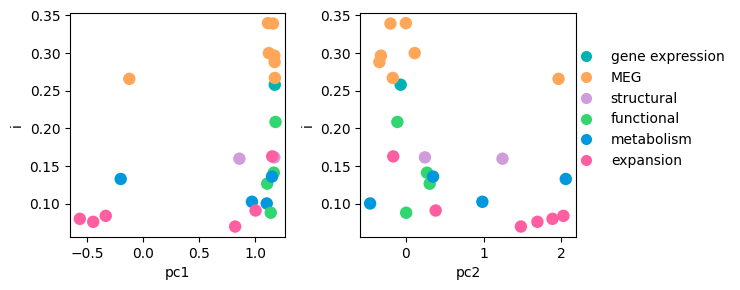

In [110]:
# add regression lines here

fig, axs = plt.subplots(1,2, figsize = (8,3))

for i, measure in enumerate(['pc1', 'pc2']):
    
    sns.scatterplot( global_i_s, x=measure, y='i', \
                    hue = 'category', palette=cpal, \
                     s=80, edgecolor = 'none',\
                     legend=False, ax=axs[i])

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markeredgecolor = 'none',\
           markerfacecolor=to_rgba(ccolours[ci]), markersize=8, \
           label=cat)
    for ci, cat in enumerate(corder)
]

plt.legend(handles=legend_elements, \
           loc='lower right', \
           frameon=False, \
           ncol = 1,\
            bbox_to_anchor=(1.75, 0.25),  # outside right
            borderaxespad=0.5)

plt.tight_layout()
#plt.show()

## fit other parametric variograms

In [132]:
# fitting multiple variograms

import gstools as gs
from interpmodules import helpers
import skgstat as skg
skgstat_mdls = {'spherical': skg.models.spherical, 
                'exponential': skg.models.exponential,
                'gaussian': skg.models.gaussian,
                'cubic': skg.models.cubic,
                'stable': skg.models.stable,
                'matern': skg.models.matern,
               'hole': helpers.hole}

In [133]:
skgstat_mdls

{'spherical': <function skgstat.models.spherical(h, r, c0, b=0.0)>,
 'exponential': <function skgstat.models.exponential(h, r, c0, b=0.0)>,
 'gaussian': <function skgstat.models.gaussian(h, r, c0, b=0.0)>,
 'cubic': <function skgstat.models.cubic(h, r, c0, b=0.0)>,
 'stable': <function skgstat.models.stable(h, r, c0, s, b=0.0)>,
 'matern': <function skgstat.models.matern(h, r, c0, s, b=0.0)>,
 'hole': <function interpmodules.helpers.hole(h, r, c0, nugget)>}

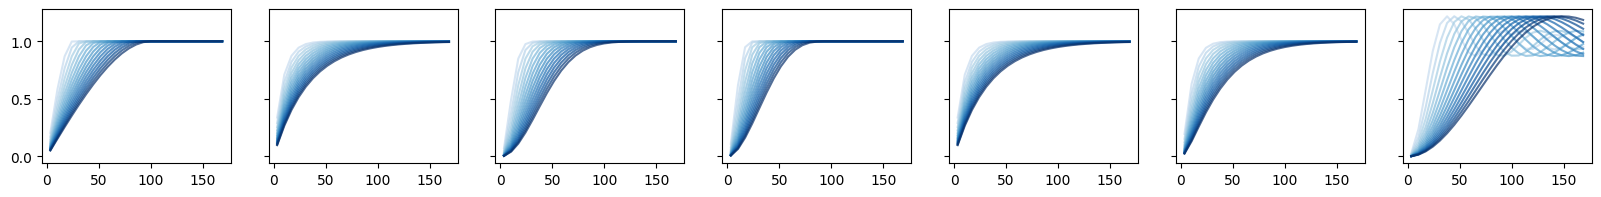

In [134]:
r=np.arange(25, 105, 5)
c0=1
nugget=0
s=1

# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('Blues')
range_colours = lincmap(np.linspace(0.25, 1, len(r)))
sns.color_palette(range_colours)

fig, axs = plt.subplots(1, 7, figsize = (20,2), sharex=True, sharey=True)

for mi, modelname in enumerate(skgstat_mdls.keys()):
    for rind, ri in enumerate(r):
        if modelname in ['stable', 'matern']:
            v_pred = skgstat_mdls[modelname](h, r=ri, c0=c0, s=1)
        elif modelname == 'hole':
            v_pred = skgstat_mdls[modelname](h, r=ri, c0=c0, nugget=0)
        else:
            v_pred = skgstat_mdls[modelname](h, r=ri, c0=c0)
        
        axs[mi].plot(h, v_pred, color = range_colours[rind], alpha = .7)

In [135]:
extended_cpal = {}

for maptag in maptags:
    extended_cpal[maptag] = cpal[global_i_s.loc[maptag]['category']]

In [140]:
import joblib
mapnames, h, all_ev = joblib.load( projdir + '/results/stats/neuromaps_collected_expvgm.pkl' )

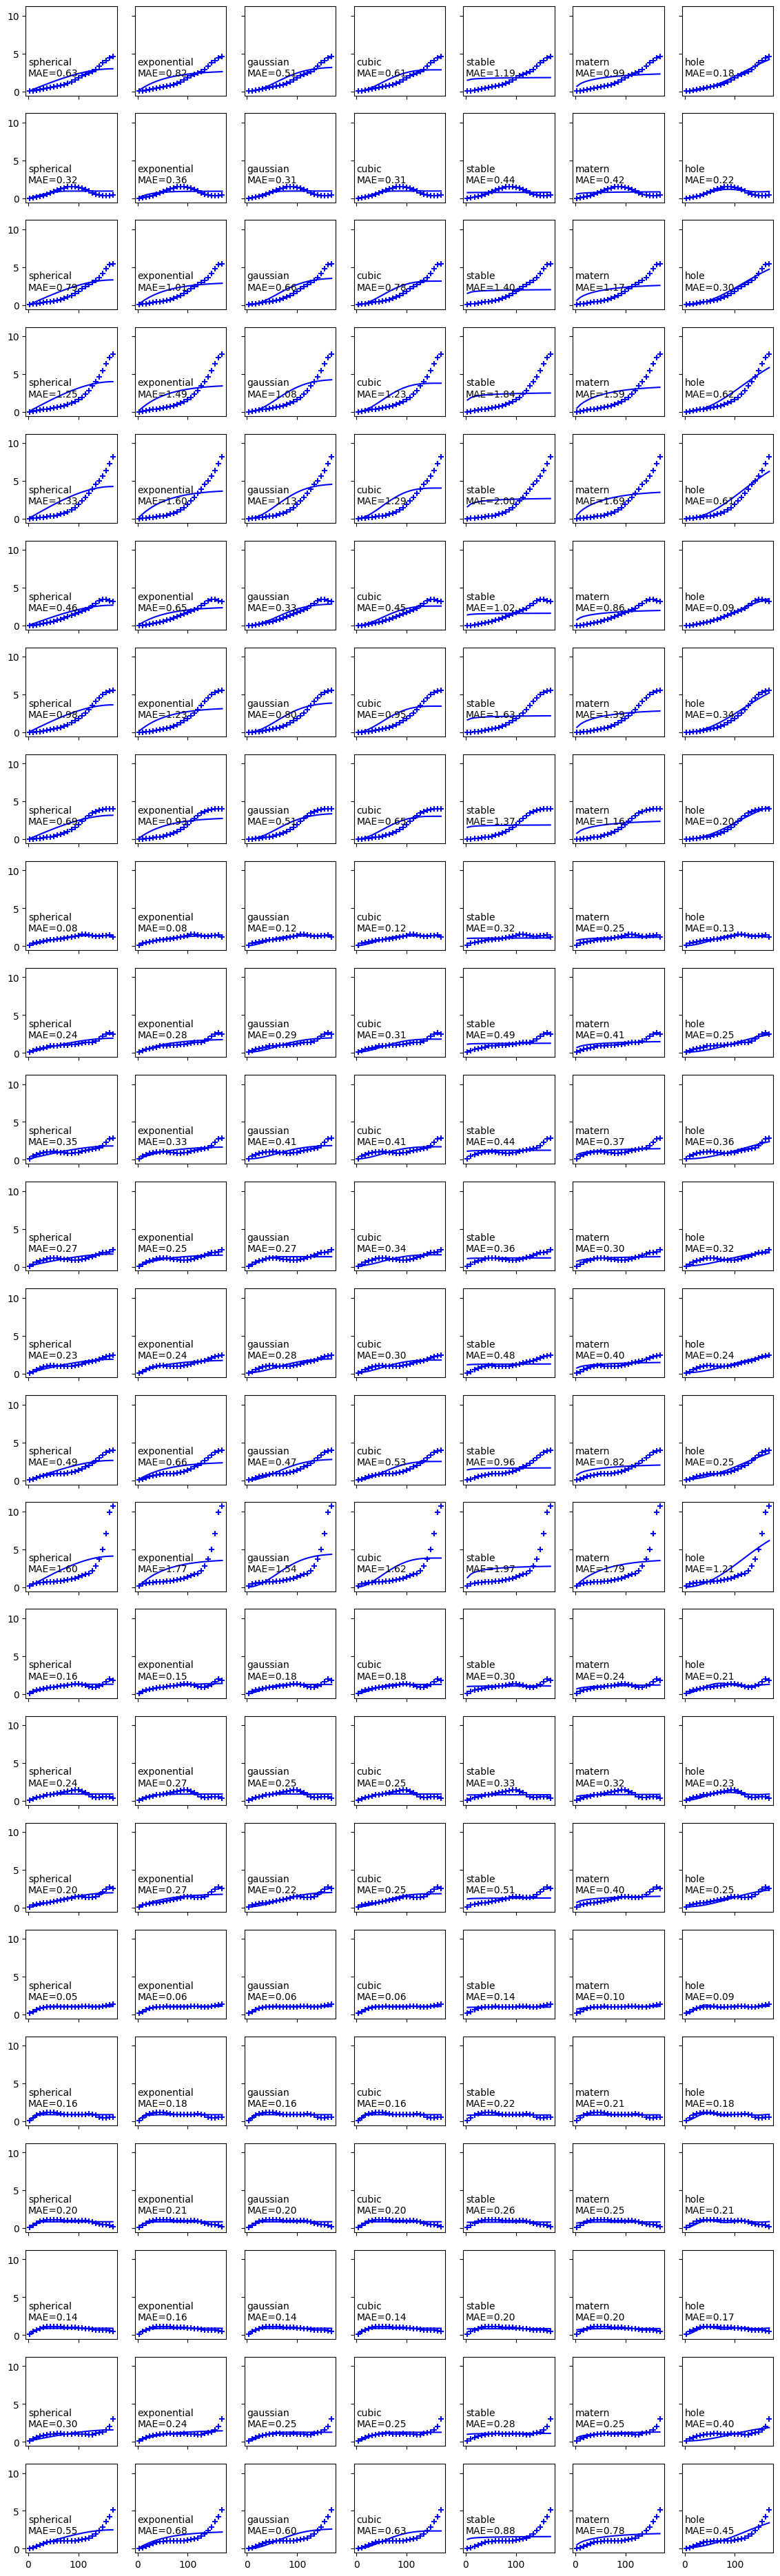

In [141]:
import matplotlib.pyplot as plt
import skgstat as skg
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from interpmodules import metrics

fig, axs = plt.subplots(24,7, figsize = (14,48), sharex=True,sharey=True)

model_scores = {}

for mi, mapname in enumerate(maptags):
    ev = all_ev[:,mi]
    nh = 25
    bounds = {3: ([0.00001]*3, [np.max(h), np.nanmax(ev), np.nanmax(ev)/nh]),
              4: ([0.00001]*4, [np.max(h), np.nanmax(ev), np.nanmax(ev)/nh, ev[0]])
             }
    
    cof = None; cov = None
    
    gof = {}
    
    for ind, model in enumerate(skgstat_mdls):
    
        axs[mi,ind].scatter(h, ev, marker = "+", color = 'b')
        
    
        if model in ['stable', 'matern']:
            cof, cov = curve_fit(skgstat_mdls[model], h, ev, method = 'trf', p0 = bounds[4][1], bounds = bounds[4], maxfev=1000)
        
        else:
            cof, cov = curve_fit(skgstat_mdls[model], h, ev, method = 'trf', p0 = bounds[3][1], bounds = bounds[3], maxfev=1000)
    
        v_pred = skgstat_mdls[model](h, *cof)
        x_s = np.linspace(h.min(), h.max())
        axs[mi, ind].plot(h, v_pred, color = 'b')
        mae = np.mean(metrics.metric(v_pred, ev, 'residual'))
        gof[model] = mae
        axs[mi, ind].text(x=0, y=2,s= model + "\n" + r'MAE=' + '{0:.2f}'.format(mae))

    model_scores[mapname] = gof

In [143]:
from scipy.stats import zscore

matrix = np.zeros((7, 24))

for mi, mapname in enumerate(mapnames):
    matrix[:, mi] = zscore( pd.DataFrame( model_scores[mapname].values(), model_scores[mapname].keys() )[0].to_numpy() )

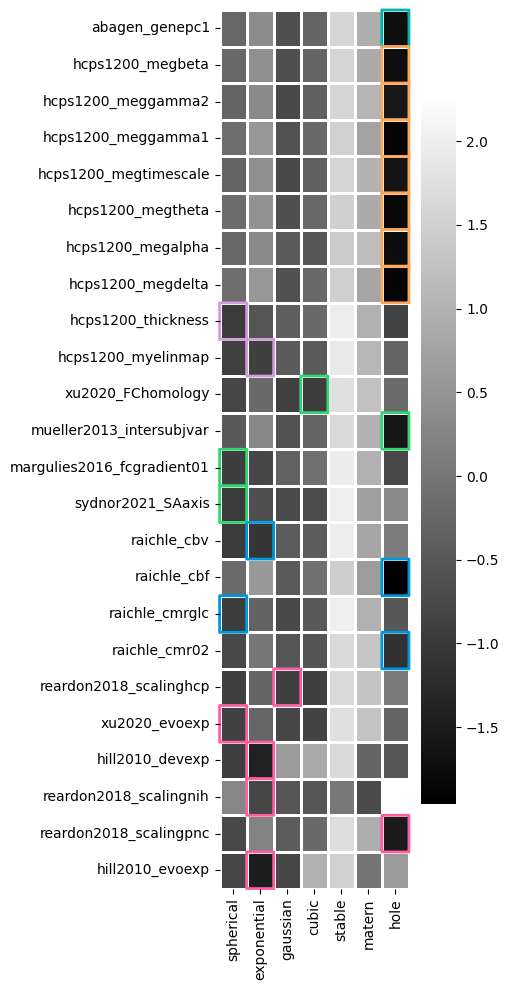

In [145]:
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
data = pd.DataFrame(matrix)

fig, ax = plt.subplots(figsize = (5,10))

sns.heatmap(matrix.T, yticklabels = mapnames, \
            linewidth = 2, linecolor = 'w', xticklabels = skgstat_mdls.keys(), cmap = 'gist_yarg_r', ax=ax)

row_labels = []

for maptag in data.columns:
    col_label = maptag
    row_label = data[maptag].sort_values(ascending = True).index[0]
    row_labels.append(row_label)


    j = data.index.get_loc(row_label)
    i = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor=extended_cpal[mapnames[maptag]],
            facecolor="none", clip_on=False
        ))
    

plt.tight_layout()

In [147]:
mdlnames = ['spherical', 'exponential', 'gaussian', 'cubic', 'stable', 'matern', 'hole']
show_models = [ mdlnames[ row_label ] for row_label in row_labels ]

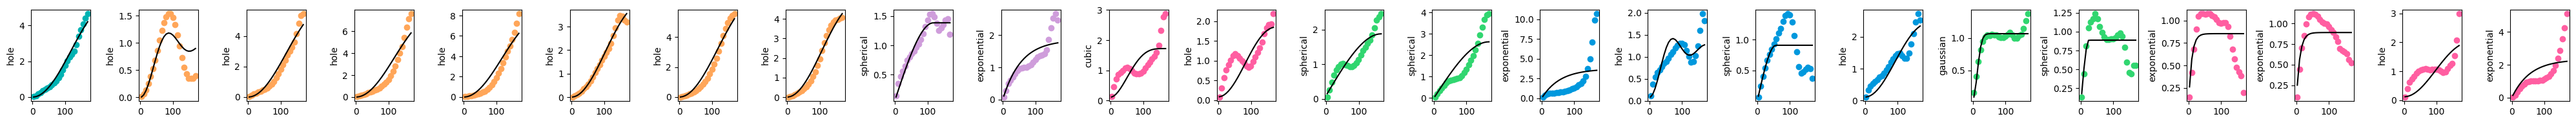

In [150]:
import matplotlib.pyplot as plt
import skgstat as skg
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from interpmodules import metrics

fig, axs = plt.subplots(1, 24, figsize = (40,2), sharex=True)

for mi, mapname in enumerate(maptags):
    ev = all_ev[:,mi]
    nh = 25
    bounds = {3: ([0.00001]*3, [np.max(h), np.nanmax(ev), np.nanmax(ev)/nh]),
              4: ([0.00001]*4, [np.max(h), np.nanmax(ev), np.nanmax(ev)/nh, ev[0]])
             }
    
    cof = None; cov = None
    
    gof = {}
        
    axs[mi].scatter(h, ev, color = extended_cpal[mapname])

    model = show_models[mi]
    if model in ['stable', 'matern']:
        cof, cov = curve_fit(skgstat_mdls[model], h, ev, method = 'trf', p0 = bounds[4][1], bounds = bounds[4], maxfev=1000)
    
    else:
        cof, cov = curve_fit(skgstat_mdls[model], h, ev, method = 'trf', p0 = bounds[3][1], bounds = bounds[3], maxfev=1000)

    v_pred = skgstat_mdls[model](h, *cof)
    x_s = np.linspace(h.min(), h.max())
    axs[mi].plot(h, v_pred, color = 'k')
    mae = np.mean(metrics.metric(v_pred, ev, 'residual'))
    gof[model] = mae
    axs[mi].set_ylabel(model)
plt.tight_layout()
plt.show()